## FastSparse: 

In [1]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
import pickle as pkl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from tqdm import tqdm

header dimension 142
lamb0:0.001, lamb2:0.5, acc:0.6709135659475894, auc:0.728105294647142, supp_size:15
pair before removing {'age': [22.0, 27.0, 32.0, 33.0, 36.0], 'juvenile_crimes': [0.0], 'priors_count': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]}
k, v age [22.0, 27.0, 32.0, 33.0, 36.0, 96]
k, v juvenile_crimes [0.0, 20]
k, v priors_count [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38]
pair after removing {'age': [22.0, 27.0, 32.0, 33.0, 36.0, 96], 'juvenile_crimes': [0.0, 20], 'priors_count': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38]}
v_count: [0, 6, 2, 9]
[ 0  6  8 17]
age 0 0
age 1 1
age 2 2
age 3 3
age 4 4
age 5 5
juvenile_crimes 0 6
juvenile_crimes 1 7
priors_count 0 8
priors_count 1 9
priors_count 2 10
priors_count 3 11
priors_count 4 12
priors_count 5 13
priors_count 6 14
priors_count 7 15
priors_count 8 16
True
True
True
(18,) hi
(18,) hi2
(6907, 18) (18,) (6907, 18) (18,)
objective: 1.0675942570197012 objective in LR 1.0675942570197012
m:1.01, log objective:1.067594257019701

<Figure size 550x400 with 0 Axes>

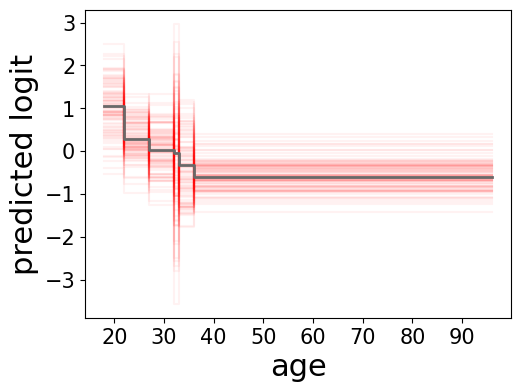

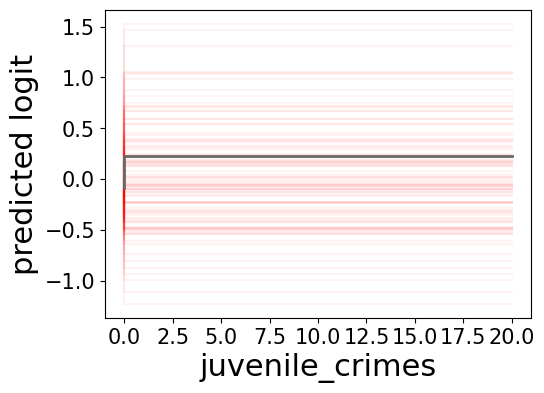

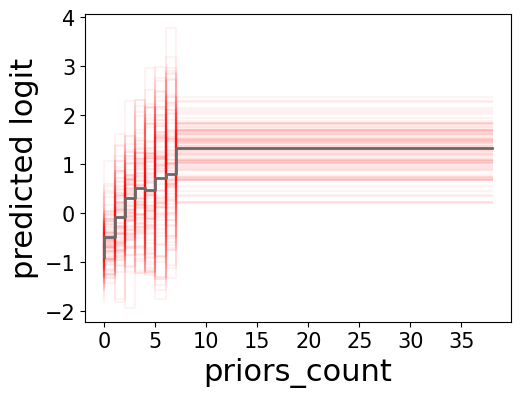

In [2]:
dname = "compas"
l0 = 0.001
l2 = 0.5
m = 1.01

betas_fastSparse = prepare_sparse_gam(dname, l0, l2, m)
filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)
w_samples = get_models_from_rset(filepath, n_samples=100, plot_shape=True, sample_from_surface=False)

In [3]:
# load the dataset
dataset_name = 'compas'
path = 'datasets/{}.csv'.format(dataset_name)
dataset = pd.read_csv(path)
dataset.iloc[:, -1][dataset.iloc[:, -1] == 0] = -1
X, y = dataset.iloc[:, :-1], dataset.iloc[:, -1]

X_one_hot, count = one_hot_encoding(X, one_hot=True)
y = pd.DataFrame(y)  # {0,1}

header = list(X_one_hot.columns)
header = pd.Index(["intercept"] + header)
header = header.astype("object")

# add a column of one to X_orig and make y in {1,-1}
X_one_hot, y = utils.get_X_y(X_one_hot, y)
y = y[:, -1]

print("header dimension", len(header), flush=True)
print(X_one_hot.shape, y.shape)

header dimension 142
(6907, 142) (6907,)


In [5]:
# load model
X_fastsparse = pkl.load(open(betas_fastSparse, 'rb'))['X']
mean_loss = 0
for i in range(len(w_samples)):
    # make predictions
    w0 = w_samples[i, :]
    logits = X_fastsparse @ w0
    y_pred = np.exp(logits)/(1+np.exp(logits))
    y_pred[y_pred > 0.5] = 1
    y_pred[y_pred <= 0.5] = -1
    # compute loss
    mean_loss += (y != y_pred).mean()
print("mean loss: {}".format(mean_loss / len(w_samples)))

mean loss: 0.37443607933980033


## FasterRisk

In [7]:
from FasterRisk.src.fasterrisk import fasterrisk

# using extended get sparse diverse pool
# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.008, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=3)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.003, select_top_m=100)
rs.optimize(generate_non_integer_solution=True, test=True, swaps=2)
beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.002, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=1)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

[  4   5   6   7   8  89 103 104 105 106]
Sampled indices: [4 3 2 1 0]


In [9]:
print(f"found {betas.shape[0]} models")
mean_loss = 0
for i in range(len(betas)):
    wi = betas[i, :]
    intercepti = beta0[i]
    logit = X_one_hot @ wi + intercepti
    y_pred = np.exp(logit) / (1 + np.exp(logit))
    y_pred = np.where(y_pred > 0.5, 1, -1)
    mean_loss += (y != y_pred).mean()
    print(np.nonzero(wi)[0], (y != y_pred).mean())
print(mean_loss / len(betas))

found 0 models


ZeroDivisionError: division by zero

In [ ]:
# save betas and beta0 to a pickle file
with open("compas_0.008_3.pkl", "wb") as f:
    pkl.dump({"betas": betas, "beta0": beta0}, f)
# load betas and beta0 from a pickle file
with open("compas_0.008_3.pkl", "rb") as f:
    data = pkl.load(f)
betas = data["betas"]
beta0 = data["beta0"]

In [ ]:
# GAMS identify artefacts in the data -> Zack
# Regularization based on data distribution?
# Constraint for hard penalty (l0) -> evaluate it on soft penalty (l2)
# Histogram of support sets (overlapping)
# Domain knowledge -> support sets
# modify beam search to only include support sets that are sufficiently different
# (where a diversity parameter is specified by the user)

(13, 142)


100%|██████████| 37/37 [00:00<00:00, 875.74it/s]


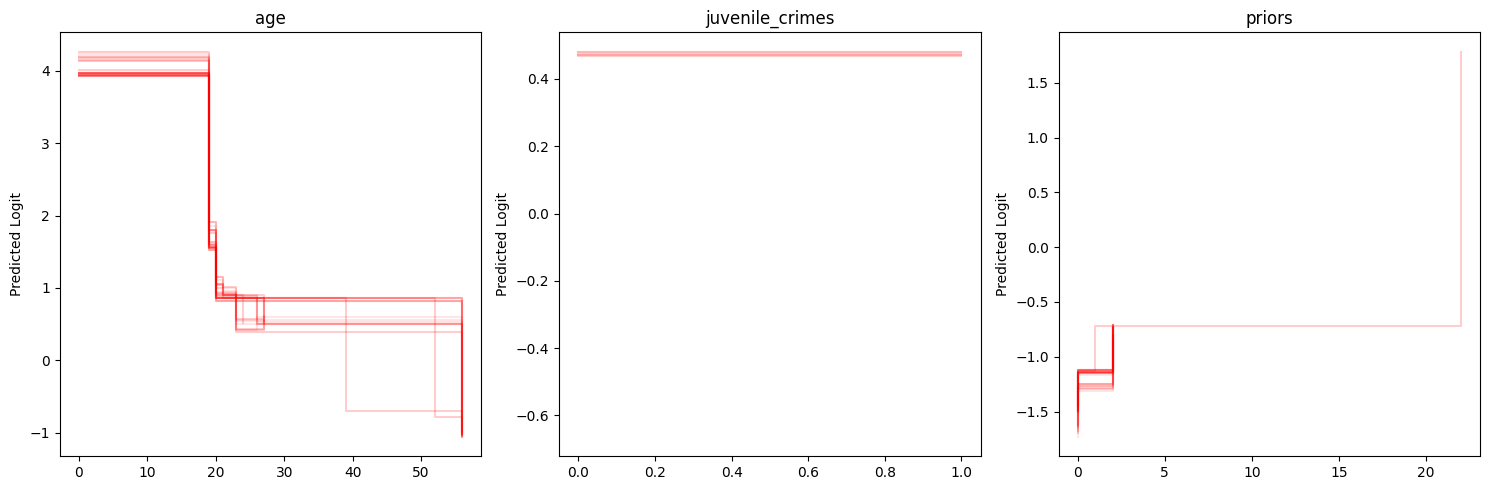

In [10]:
def get_feature_thresholds(weights, columns):
    feature_thresholds = defaultdict(list)
    for col, weight in zip(columns, weights):
        match = re.search(r'([a-zA-Z]+)', col)
        if match:
            feature = match.group(1)
            threshold = re.findall(r'[\d.]+', col)
            if feature == 'juv':
                feature = 'juv_misd_count'
            if feature == 'juvenile':
                feature = 'juvenile_crimes'
            feature_thresholds[feature].append((list(map(float, threshold)), weight))
    return feature_thresholds

def plot_gam(header, list_of_weights):
    rows = 1; cols = 3
    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 5 * rows))
    axs = axs.flatten()
    ax_dict = {}
    counter = 0
    union_of_support_sets = defaultdict(int)
    for i in tqdm(range(len(list_of_weights))):
        weights = list_of_weights[i, :]
        columns = header[np.nonzero(weights)[0]]
        weights = weights[np.nonzero(weights)[0]]
        for column in columns:
            union_of_support_sets[column] += 1

        feature_thresholds = get_feature_thresholds(weights, columns)
        for feature, thresholds_weights in feature_thresholds.items():
            if feature == 'sex' or feature == 'current':
                continue
            if feature not in ax_dict:
                ax = axs[counter]
                ax_dict[feature] = ax
                counter += 1
            else:
                ax = ax_dict[feature]
            thresholds, feature_weights = zip(*thresholds_weights)

            x_vals, y_vals = [], []
            x_vals.append(0)
            y_vals.append(feature_weights[0])
            for i in range(len(thresholds) - 1):
                x_vals.append(thresholds[i][0])
                y_vals.append(feature_weights[i])

            # For the last value of the interval, add it once more
            x_vals.append(thresholds[-1][-1])
            y_vals.append(feature_weights[-1])

            ax.step(x_vals, y_vals, where="post", color='r', alpha=0.1)
            ax.set_ylabel("Predicted Logit")
            ax.set_title(feature)
    plt.tight_layout()
    plt.show()
    return union_of_support_sets

union_of_support_sets = plot_gam(header, betas[:100, :])

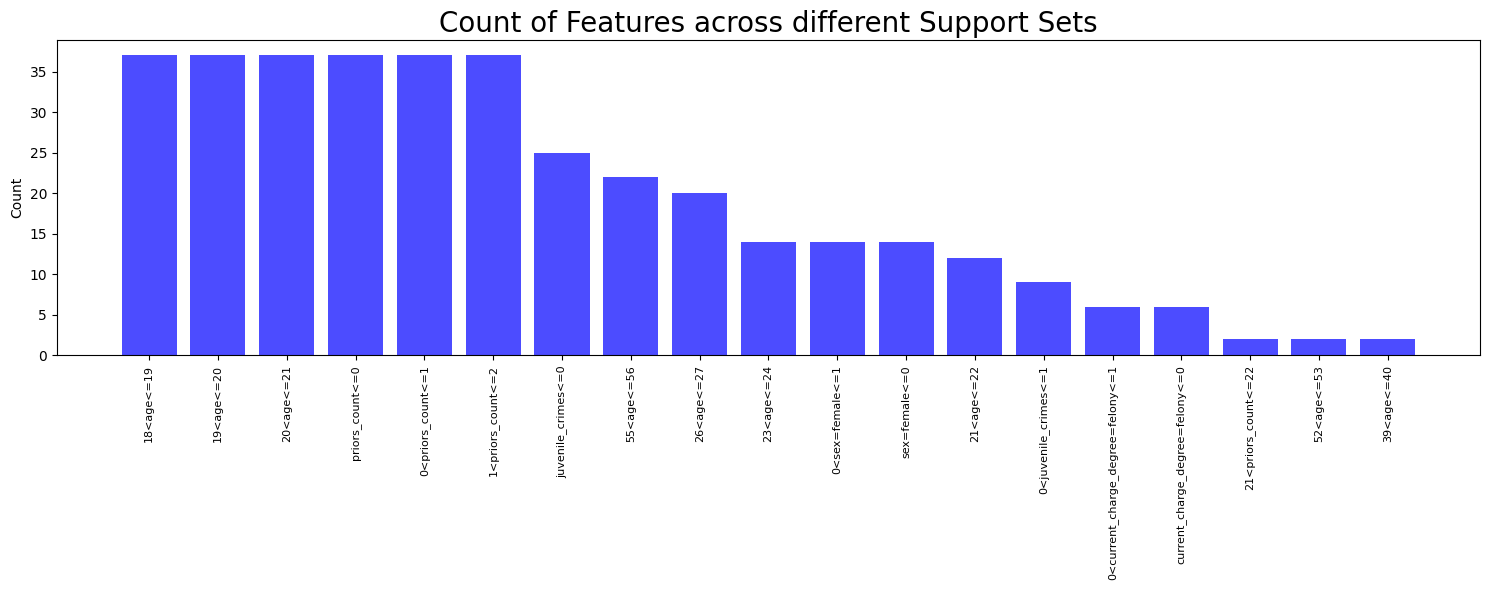

In [11]:
# Given dictionary
sorted_data = dict(sorted(union_of_support_sets.items(), key=lambda x: x[1], reverse=True))

# Prepare data for histogram
keys = list(sorted_data.keys())
values = list(sorted_data.values())

# Plot histogram
plt.figure(figsize=(15, 6))
plt.bar(keys, values, color='blue', alpha=0.7)
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Count')
plt.title('Count of Features across different Support Sets', fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
# header = pkl.load(open(betas_fastSparse, 'rb'))['header_new']
# header = [i.replace('.0', '') for i in header]
# print(keys)
# print(header)

# for key in keys[:15]:
#     print(header,key)
# if key in header:
#     print(key)

['18<age<=19', '19<age<=20', '20<age<=21', 'priors_count<=0', '0<priors_count<=1', '1<priors_count<=2', '26<age<=27', 'juvenile_crimes<=0', '55<age<=56', '23<age<=24', '0<sex=female<=1', 'sex=female<=0', '21<age<=22', '0<juvenile_crimes<=1', '0<current_charge_degree=felony<=1', 'current_charge_degree=felony<=0']
['intercept', 'age<=22', '22<age<=27', '27<age<=32', '32<age<=33', '33<age<=36', '36<age<=96', 'juvenile_crimes<=0', '0<juvenile_crimes<=20', 'priors_count<=0', '0<priors_count<=1', '1<priors_count<=2', '2<priors_count<=3', '3<priors_count<=4', '4<priors_count<=5', '5<priors_count<=6', '6<priors_count<=7', '7<priors_count<=38']
